# Classificação, Detecção e Segmentação de Imagens

In [1]:
!pip install ultralytics
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.2 MB/s eta 0:00:00


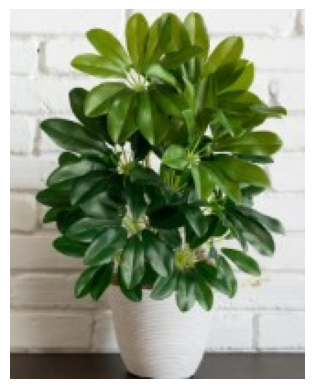

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("planta.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [3]:
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision.models import vit_b_16, ViT_B_16_Weights

img = Image.open("planta.jpg").convert("RGB")

weights = ViT_B_16_Weights.IMAGENET1K_V1

model = vit_b_16(weights=weights)
model.eval()

preprocess = weights.transforms()

img_input = preprocess(img).unsqueeze(0)

with torch.no_grad():
    output = model(img_input)
    probs = F.softmax(output[0], dim=0)

top5_prob, top5_idx = torch.topk(probs, 5)

categorias = weights.meta["categories"]

print("Top 5 classes:")

for i in range(5):
    print(
        categorias[top5_idx[i]],
        f"{top5_prob[i].item()*100:.2f}%"
    )

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 155MB/s]


Top 5 classes:
pot 88.88%
vase 0.92%
milk can 0.79%
daisy 0.44%
soap dispenser 0.19%


## Classificação com Vision Transformer (ViT)

O modelo Vision Transformer foi utilizado para classificar a imagem da planta utilizando as categorias do ImageNet.

In [4]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

image = Image.open("planta.jpg")

model = CLIPModel.from_pretrained(
    "openai/clip-vit-large-patch14"
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-large-patch14"
)

labels = [
    "plant",
    "flower",
    "tree",
    "leaf",
    "garden",
    "grass"
]

inputs = processor(
    text=labels,
    images=image,
    return_tensors="pt",
    padding=True
)

outputs = model(**inputs)

probs = outputs.logits_per_image.softmax(dim=1)

for label, p in zip(labels, probs[0]):
    print(
        f"{label:15s} {100*p.item():.2f}%"
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

plant           97.49%
flower          1.51%
tree            0.28%
leaf            0.59%
garden          0.03%
grass           0.11%


## Classificação com CLIP

O modelo CLIP compara imagens e descrições textuais, permitindo classificações mais flexíveis do que modelos treinados apenas com classes fixas.

In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model("transito.jpg")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/transito.jpg: 416x640 30 cars, 1 bus, 3 trucks, 288.4ms
Speed: 14.7ms preprocess, 288.4ms inference, 19.1ms postprocess per image at shape (1, 3, 416, 640)


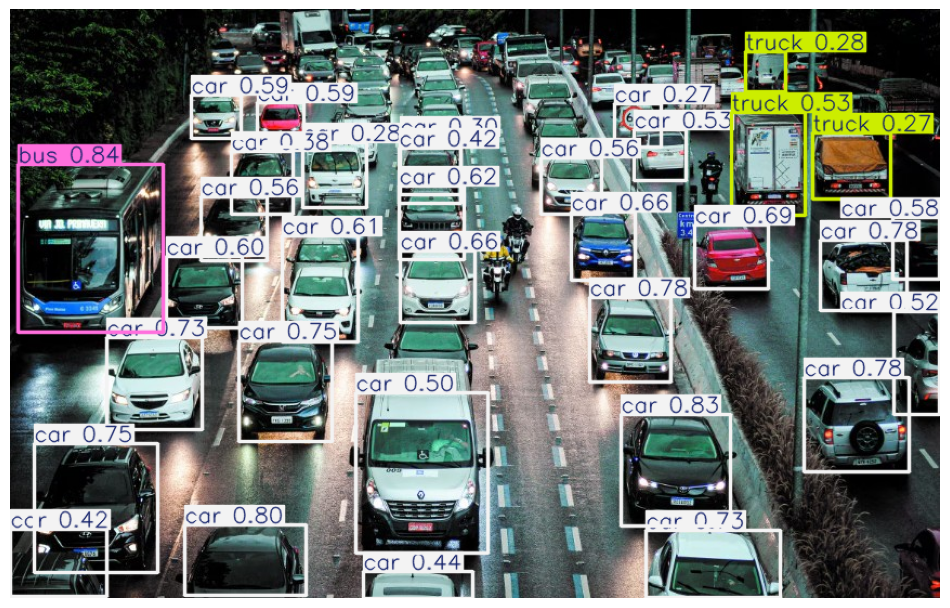

In [6]:
import matplotlib.pyplot as plt

img = results[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(img[:,:,::-1])
plt.axis("off")
plt.show()

## Detecção de Objetos com YOLO

O YOLO identificou automaticamente objetos presentes na imagem de trânsito por meio de caixas delimitadoras.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("planta.jpg")

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

hsv = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2HSV
)

lower_green = np.array([35,40,40])
upper_green = np.array([85,255,255])

mask = cv2.inRange(
    hsv,
    lower_green,
    upper_green
)

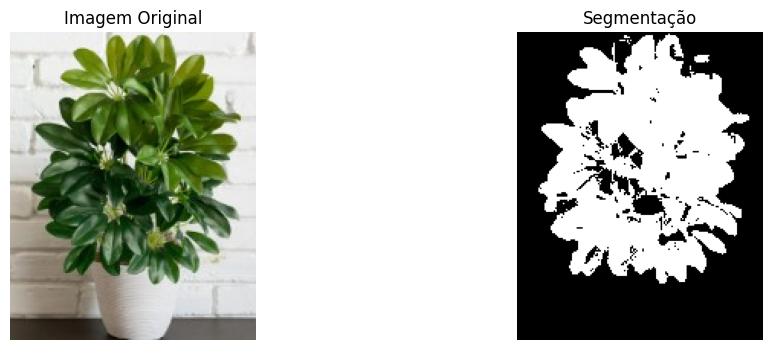

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="gray")
plt.title("Segmentação")
plt.axis("off")

plt.show()

# Conclusão

Nesta atividade foram exploradas três abordagens distintas de visão computacional.

A classificação de imagens foi realizada por meio dos modelos ViT e CLIP, a detecção de objetos foi realizada utilizando YOLO e a segmentação foi executada com OpenCV utilizando técnicas baseadas em cor.

Os resultados demonstram que cada abordagem possui objetivos específicos e complementares dentro das aplicações de Visão Computacional e Deep Learning.